# Universidad de Buenos Aires
# Aprendizaje Profundo - TP2
# Cohorte 26 - 4to bimestre 2026

## **Alumno 1:** Rodrigo Hernández

El segundo TP comienza la semana de la clase 4 y la ventana de entrega estará abierta hasta las **23:59 hs del domingo 4 de octubre (hora de Argentina)**.

La resolución del TP puede realizarse de forma **individual, en parejas o hasta en grupos de 3 como máximo**. Sin embargo, no se recomienda repartir las preguntas entre los integrantes, sino que todos los integrantes deben trabajar conjuntamente en la resolución de cada pregunta. De esta manera, se promueve el debate, la discusión y la construcción de una conclusión compartida sobre cómo abordar y resolver cada pregunta.

Pueden utilizar tanto los contenidos vistos en clase, como otra bibliografía externa. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP2 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Importante permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

**El desarrollo del TP se debe hacer obligatoriamente en un notebook**, ya sea en un Google Colab o en un Jupyter Notebook para quienes quieran desarrollarlo en su propia PC local. Pero no se aceptarán archivos `.py` o links a repos de github con múltiples archivos. El entregable debe ser un link a un único archivo en formato `.ipynb`.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/PGDTphbnqZpcVK167)**. Tanto los resultados, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el colab.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP2.
- Renombrar el archivo de la siguiente manera: **PRIMERAPELLIDOALUMNO1-PRIMERAPELLIDOALUMNO2-PRIMERAPELLIDOALUMNO3-TP2-Co26.ipynb**
O en caso hacerlo individual usar: **PRIMERAPELLIDO-PRIMERNOMBRE-TP2-Co26.ipynb**
- Los códigos deben poder ejecutarse.
- **IMPORTANTE:** Los resultados, cómo el código, los gráficos, los prints y las explicaciones deben quedar guardados y visualizables en el mismo notebook.
- No ocultar celdas, todas se deben poder ver desde el inicio.
- **Prestar mucha atención a cada consigna, responder las preguntas justo debajo del enunciado que corresponda.**
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# CASO: Adult Census Income

El objetivo del trabajo es construir un modelo de clasificación binaria que, a partir de los datos censales de diferentes hogares, determine si un individuo pertenece al grupo de mayores o de menores ingresos. Para ello, se empleará un conjunto de variables demográficas, laborales y socioeconómicas que describen las características de cada persona. El estudio debe incluir el análisis exploratorio del dataset, la selección y justificación de las transformaciones más adecuadas para cada variable, la construcción de modelos basados tanto en técnicas de codificación tradicionales como también en representaciones avanzadas mediante embeddings, y la comparación final del desempeño obtenido por cada enfoque.

**Para este caso de estudio, consideraremos como variable de alta cardinalidad a las que tengan 10 o más valores únicos.**


**Encontrarán el dataset en el siguiente enlace de drive: [link](https://drive.google.com/drive/folders/1S-usUXkJP6OdzUS0zdC5CW-XqegiXzln?usp=sharing)**

Está compuesto por los siguientes features:
- **age**: Edad del individuo expresada en años.

- **workclass**: Tipo de empleador o relación laboral del individuo. Describe si trabaja en el sector privado, gobierno estatal, local, federal, por cuenta propia, sin remuneración, etc.

- **education**: Nivel educativo alcanzado. Incluye categorías como secundaria completada, licenciatura, maestría, doctorado, etc.

- **marital-status**: Estado civil (casado, nunca casado, divorciado, viudo, etc.).

- **occupation**: Tipo de ocupación o área laboral, donde se incluye ventas, servicios de protección, técnicos, gerencia ejecutiva, fuerzas armadas, etc.

- **relationship**: Relación del individuo con el jefe del hogar como esposo, esposa, hijo propio, pariente, no familiar, etc.

- **race**: Autoidentificación racial como blanca, negra, indígena, asiática, isleños del Pacífico, entre otras.

- **sex**: Sexo biológico del individuo (masculino o femenino).

- **capital-gain**: Ingresos obtenidos por ganancia de capital (por ejemplo, venta de acciones o propiedades).

- **capital-loss**: Pérdidas declaradas por capital.

- **hours-per-week**: Cantidad de horas trabajadas por semana.

- **skill-profile**: Habilidad principal o conocmiento técnico adquirido que podría aplicar en el trabajo.

- **native-country**: País de nacimiento del individuo. Incluye Estados Unidos y una lista amplia de países del mundo.

- **income (target)**: Clasificación binaria que indica si el ingreso anual del individuo es menor o igual a 50K o mayor a 50K.

## a) Análisis exploratorio de los datasets (2 puntos)

- Realizar un EDA apoyado en gráficas adecuadas y coherentes para el caso de estudio.
- Analizar detalladamente los valores únicos de cada variable categórica e identificar su nivel de cardinalidad.
- Justificar de manera detallada el tipo de transformación que se le asignará a cada variable, en especial a las categóricas. **Dependiendo de su cardinalidad, su contexto y/o lógica interna de orden**, podrán transformarse mediante label/ordinal encoding, one-hot encoding o mediante una capa de embeddings dentro del modelo.
- No es necesario aplicar la misma transformación para todas las variables categóricas. El dataset puede (y debe) incluir diferentes tipos de transformaciones según las características de cada variable.
- Redactar explícitamente la decisión final adoptada para cada variable y su justificación correspondiente.

#### Respuesta a)

In [18]:
# ----------------------------------------------------------------------
# DESCARGA Y PRIMERA INSPECCIÓN
# ----------------------------------------------------------------------
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# La carpeta de Drive trae dos archivos: el split train / validación ya viene hecho.
ARCHIVOS = {"adult_train.csv": "14NaASnZwTM2amJnMxz5E_6rczadZF4Zq",
            "adult_val.csv":   "1tS0FPVDQ7cy1COgRZfS03oeOEHbOvSkN"}
os.makedirs("data", exist_ok=True)
for nombre, id_drive in ARCHIVOS.items():
    if not os.path.exists(f"data/{nombre}"):          # en Colab se descargan de Drive
        import gdown
        gdown.download(id=id_drive, output=f"data/{nombre}", quiet=True)

train = pd.read_csv("data/adult_train.csv")
val   = pd.read_csv("data/adult_val.csv")

NUMERICAS   = ["age", "capital-gain", "capital-loss", "hours-per-week"]
CATEGORICAS = ["workclass", "education", "marital-status", "occupation", "relationship",
               "race", "sex", "skill-profile", "native-country"]
assert set(NUMERICAS + CATEGORICAS + ["income"]) == set(train.columns) == set(val.columns)

for nombre, d in [("train", train), ("validación", val)]:
    print(f"{nombre:11} {len(d):>6,} filas x {d.shape[1]} columnas | nulos: {d.isna().sum().sum()} | "
          f"celdas con '?': {(d == '?').sum().sum()} | filas repetidas: {d.duplicated().sum()} "
          f"({d.duplicated().mean():.1%})")

print(f"\n{len(NUMERICAS)} numéricas: {NUMERICAS}")
print(f"{len(CATEGORICAS)} categóricas: {CATEGORICAS}")
print("target: income")
train.head()

train       30,162 filas x 14 columnas | nulos: 0 | celdas con '?': 0 | filas repetidas: 479 (1.6%)
validación  15,060 filas x 14 columnas | nulos: 0 | celdas con '?': 0 | filas repetidas: 118 (0.8%)

4 numéricas: ['age', 'capital-gain', 'capital-loss', 'hours-per-week']
9 categóricas: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'skill-profile', 'native-country']
target: income


,age,workclass,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,skill-profile,native-country,income
0,39,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,manufacturing_assembly,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,accounting_bookkeeping,United-States,<=50K
2,38,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,agriculture_field_work,United-States,<=50K
3,53,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,office_data_entry_basic,United-States,<=50K
4,28,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,tech_programming_advanced,Cuba,<=50K


##### Primera inspección

Los dos archivos tienen las mismas 14 columnas: 4 numéricas, 9 categóricas y el target, `income`. No hay nulos ni celdas con `?`, que es como el dataset original de UCI marca los datos faltantes. Además, 30.162 y 15.060 son exactamente las filas que les quedan a los archivos originales de train y de test cuando se sacan las que tenían algún `?` ([UCI, adult.names](https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.names)). O sea que los faltantes ya se limpiaron antes y no hay nada que imputar.

Hay 479 filas repetidas en train (1.6%). No las borro. No hay ninguna columna que identifique a la persona, y con 13 variables tan generales es esperable que dos personas distintas coincidan en todo: misma edad, mismo trabajo, 40 horas semanales, sin ganancias de capital.

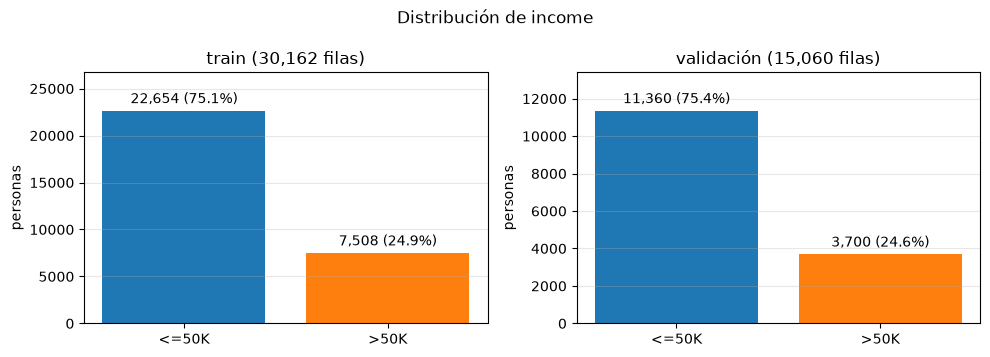

Predecir siempre <=50K ya acierta el 75.1% en train y el 75.4% en validación.

                media train  media validación
age                   38.44             38.77
capital-gain        1092.01           1120.30
capital-loss          88.37             89.04
hours-per-week        40.93             40.95

mayor diferencia en la proporción de una categoría entre train y validación: 0.8% (en relationship)


In [19]:
# ----------------------------------------------------------------------
# LA VARIABLE A PREDECIR, Y SI VALIDACIÓN SE PARECE A TRAIN
# ----------------------------------------------------------------------
CLASES = ["<=50K", ">50K"]
COLOR  = {"<=50K": "tab:blue", ">50K": "tab:orange"}

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, (nombre, d) in zip(axes, [("train", train), ("validación", val)]):
    conteo = d["income"].value_counts().reindex(CLASES)
    barras = ax.bar(CLASES, conteo, color=[COLOR[c] for c in CLASES])
    ax.bar_label(barras, labels=[f"{n:,} ({n / len(d):.1%})" for n in conteo], padding=3)
    ax.set_title(f"{nombre} ({len(d):,} filas)")
    ax.set_ylim(0, conteo.max() * 1.18); ax.set_ylabel("personas"); ax.grid(alpha=.3, axis="y")
fig.suptitle("Distribución de income")
fig.tight_layout(); plt.show()

alto = (train["income"] == ">50K").astype(int)       # 1 si gana más de 50K, para calcular proporciones
tasa_global = alto.mean()
print(f"Predecir siempre <=50K ya acierta el {1 - tasa_global:.1%} en train y el "
      f"{(val['income'] == '<=50K').mean():.1%} en validación.\n")

# Las variables también tienen que parecerse, no solo el target
print(pd.DataFrame({"media train": train[NUMERICAS].mean(), "media validación": val[NUMERICAS].mean()}).round(2).to_string())
dif = {c: train[c].value_counts(normalize=True).sub(val[c].value_counts(normalize=True), fill_value=0).abs().max()
       for c in CATEGORICAS}
print(f"\nmayor diferencia en la proporción de una categoría entre train y validación: {max(dif.values()):.1%} "
      f"(en {max(dif, key=dif.get)})")

##### El target

En train el 24.9% gana más de 50K y en validación el 24.6%. Las variables también se parecen entre los dos archivos: las medias de las numéricas casi coinciden (la edad promedio es 38.44 en train y 38.77 en validación) y ninguna categoría cambia su proporción en más de 0.8% de un archivo al otro. Validación es una muestra representativa de lo mismo.

El desbalance es de uno a tres. No es extremo, pero alcanza para que el accuracy engañe: un modelo que responda siempre <=50K, sin mirar ningún dato, ya acierta el 75.4% en validación. Por eso además del accuracy miro el F1 macro, que calcula el F1 de cada clase por separado y los promedia, así la clase chica pesa lo mismo que la grande. No rebalanceo las clases.

In [20]:
# ----------------------------------------------------------------------
# VALORES ÚNICOS, CARDINALIDAD Y ASOCIACIÓN CON EL TARGET
# ----------------------------------------------------------------------
from scipy.stats.contingency import association

UMBRAL_ALTA = 10          # 10 o más valores únicos = alta cardinalidad

tabla = pd.DataFrame({
    "únicos train": train[CATEGORICAS].nunique(),
    "únicos val":   val[CATEGORICAS].nunique(),
    "más rara en train": [f"{train[c].value_counts().idxmin()} ({train[c].value_counts().min()})"
                          for c in CATEGORICAS],
    "solo en train": [", ".join(sorted(set(train[c]) - set(val[c]))) or "-" for c in CATEGORICAS],
    "solo en val":   [", ".join(sorted(set(val[c]) - set(train[c]))) or "-" for c in CATEGORICAS],
    # 0 = la proporción de >50K es igual en todas las categorías; 1 = la categoría decide la clase
    "V de Cramér": [association(pd.crosstab(train[c], train["income"]), method="cramer") for c in CATEGORICAS],
}).sort_values("únicos train")
tabla.insert(2, "cardinalidad", np.where(tabla["únicos train"] >= UMBRAL_ALTA, "alta", "baja"))
print(tabla.round(3).to_string())

print("\nValores de cada una, del más frecuente al menos frecuente:")
for c in tabla.index:
    print(f"\n{c} ({train[c].nunique()}): {', '.join(train[c].value_counts().index)}")

                únicos train  únicos val cardinalidad                 más rara en train       solo en train solo en val  V de Cramér
sex                        2           2         baja                     Female (9782)                   -           -        0.217
race                       5           5         baja                       Other (231)                   -           -        0.100
relationship               6           6         baja              Other-relative (889)                   -           -        0.455
workclass                  7           7         baja                  Without-pay (14)                   -           -        0.163
marital-status             7           7         baja            Married-AF-spouse (21)                   -           -        0.448
occupation                14          14         alta                  Armed-Forces (9)                   -           -        0.350
education                 16          16         alta                

##### Valores únicos y cardinalidad

Con el umbral de 10 valores únicos hay cuatro variables de alta cardinalidad: occupation (14), education (16), native-country (41) y skill-profile (80). Las otras cinco tienen entre 2 y 7.

Train y validación tienen las mismas categorías, con una sola excepción: Holand-Netherlands aparece una vez en train y nunca en validación. El caso problemático sería el contrario, una categoría de validación que no esté en train, y eso no pasa en ninguna variable. Así que no voy a tener que codificar valores que el modelo nunca vio.

Algunas categorías tienen muy pocas filas: Armed-Forces 9, Without-pay 14 y Married-AF-spouse 21. No las junto con otras. En un one-hot una columna que casi siempre vale cero no molesta, y en un embedding el vector de una categoría así queda mal estimado, pero afecta a muy pocas filas. Algunos países vienen mal escritos o cortados desde el dataset original (Columbia, Hong, South, Trinadad&Tobago), pero son solo etiquetas y no cambian nada.

La última columna es la V de Cramér entre cada variable e income. Va de 0 a 1: vale 0 si la proporción de >50K es la misma en todas las categorías, y se acerca a 1 cuanto más decide la categoría la clase. La uso para comparar cuánto separa cada variable. skill-profile es la que más separa (0.623), seguida por relationship (0.455) y marital-status (0.448), y las que menos separan son native-country (0.103) y race (0.100), casi empatadas.

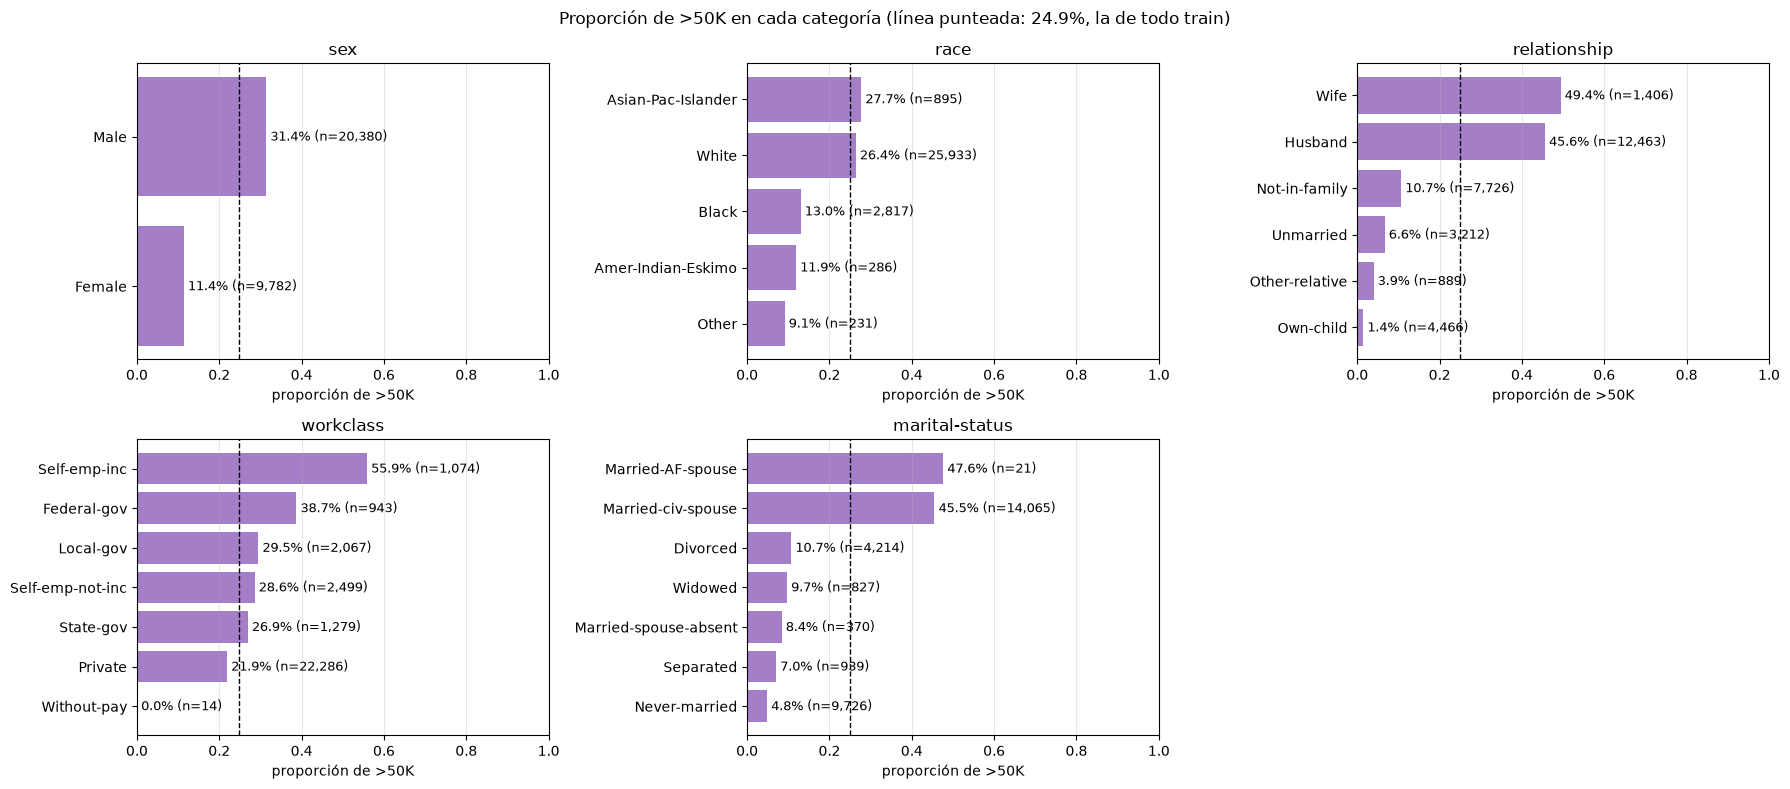

relationship vs sex (filas de train):
sex             Female   Male
relationship                 
Husband              1  12462
Not-in-family     3566   4160
Other-relative     386    503
Own-child         1961   2505
Unmarried         2463    749
Wife              1405      1


In [21]:
# ----------------------------------------------------------------------
# CATEGÓRICAS DE BAJA CARDINALIDAD FRENTE AL TARGET
# ----------------------------------------------------------------------
def barras_tasa(ax, col):
    """Proporción de >50K en cada categoría de col, con la cantidad de filas de cada una."""
    g = alto.groupby(train[col]).agg(["size", "mean"]).sort_values("mean")
    barras = ax.barh(g.index, g["mean"], color="tab:purple", alpha=.85)
    ax.bar_label(barras, labels=[f"{m:.1%} (n={n:,})" for n, m in zip(g["size"], g["mean"])],
                 padding=3, fontsize=9)
    ax.axvline(tasa_global, color="k", ls="--", lw=1)
    ax.set_xlim(0, 1); ax.set_title(col); ax.set_xlabel("proporción de >50K"); ax.grid(alpha=.3, axis="x")
    return g

BAJA = ["sex", "race", "relationship", "workclass", "marital-status"]
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, c in zip(axes.flat, BAJA):
    barras_tasa(ax, c)
axes.flat[-1].axis("off")
fig.suptitle(f"Proporción de >50K en cada categoría (línea punteada: {tasa_global:.1%}, la de todo train)")
fig.tight_layout(); plt.show()

print("relationship vs sex (filas de train):")
print(pd.crosstab(train["relationship"], train["sex"]).to_string())

##### Categóricas de pocos valores

Las cinco separan las clases, aunque con fuerzas muy distintas:

- marital-status y relationship son las que más separan de las cinco (V de 0.448 y 0.455). Married-civ-spouse tiene 45.5% de >50K contra 4.8% de Never-married. En relationship, Husband tiene 45.6%, Wife 49.4% y Own-child apenas 1.4%.
- sex: 31.4% en los hombres contra 11.4% en las mujeres (V de 0.217).
- workclass: Self-emp-inc llega a 55.9% y Without-pay a 0%, pero la V es baja (0.163) porque esas categorías tienen pocas filas: Private, con 22.286 filas, queda en 21.9%, muy cerca de la proporción global.
- race es la que menos separa (V de 0.100). La mayoría de las filas son White (25.933) y su 26.4% casi no se aleja del 24.9% global.

Ninguna tiene un orden natural: no se puede decir que Divorced sea más o menos que Widowed. Un label encoding, que numera las categorías 0, 1, 2..., le impondría al modelo un orden y unas distancias que no existen. Con tan pocos valores, one-hot es la opción directa, y agrega 7 + 7 + 6 + 5 = 25 columnas. Para sex uso una sola columna binaria (Male = 1), que con dos valores dice lo mismo que el one-hot y es más simple. En las otras dejo todas las columnas del one-hot aunque siempre sumen 1: esa redundancia es un problema para una regresión lineal, pero a una red no le molesta.

relationship repite en parte lo que dicen sex y marital-status: en train todos los Husband menos uno son hombres, y todas las Wife menos una son mujeres. No la saco igual, porque también distingue cosas que las otras dos no ven, como Own-child, el hijo que vive con sus padres, que casi nunca supera los 50K.

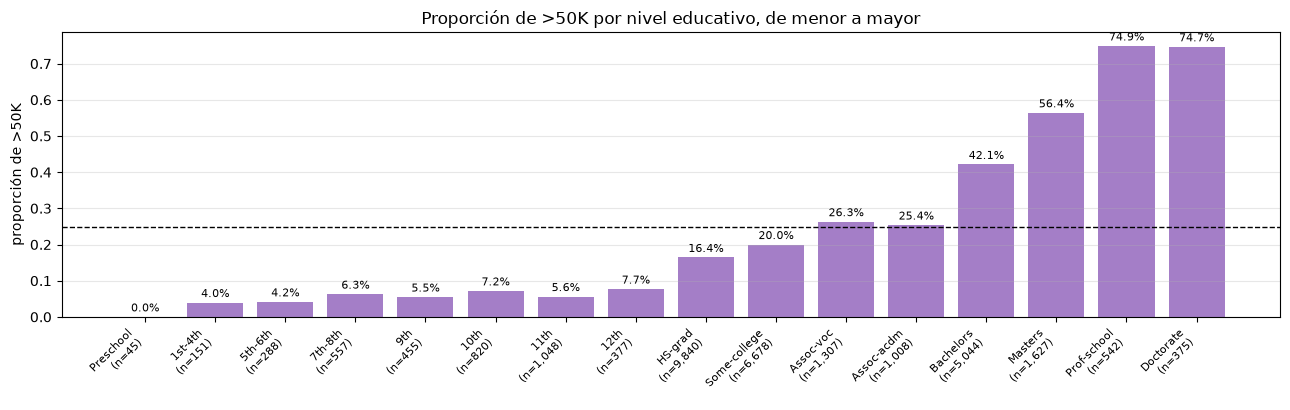

Correlación de Spearman entre la posición en el orden y la proporción de >50K: 0.979

Pares consecutivos donde la proporción baja en vez de subir:
  7th-8th        6.3%  ->  9th            5.5%
  10th           7.2%  ->  11th           5.6%
  Assoc-voc     26.3%  ->  Assoc-acdm    25.4%
  Prof-school   74.9%  ->  Doctorate     74.7%


In [22]:
# ----------------------------------------------------------------------
# EDUCATION: ¿EL TARGET RESPETA EL ORDEN NATURAL?
# ----------------------------------------------------------------------
ORDEN_EDUCACION = ["Preschool", "1st-4th", "5th-6th", "7th-8th", "9th", "10th", "11th", "12th",
                   "HS-grad", "Some-college", "Assoc-voc", "Assoc-acdm", "Bachelors", "Masters",
                   "Prof-school", "Doctorate"]
assert set(ORDEN_EDUCACION) == set(train["education"])

g = alto.groupby(train["education"]).agg(["size", "mean"]).reindex(ORDEN_EDUCACION)

fig, ax = plt.subplots(figsize=(13, 4.2))
barras = ax.bar(range(len(g)), g["mean"], color="tab:purple", alpha=.85)
ax.bar_label(barras, labels=[f"{m:.1%}" for m in g["mean"]], padding=2, fontsize=8)
ax.set_xticks(range(len(g)), [f"{e}\n(n={n:,})" for e, n in zip(g.index, g["size"])],
              rotation=45, ha="right", fontsize=8)
ax.axhline(tasa_global, color="k", ls="--", lw=1)
ax.set_ylabel("proporción de >50K"); ax.grid(alpha=.3, axis="y")
ax.set_title("Proporción de >50K por nivel educativo, de menor a mayor")
fig.tight_layout(); plt.show()

rho = pd.Series(range(len(g)), index=g.index).corr(g["mean"], method="spearman")
print(f"Correlación de Spearman entre la posición en el orden y la proporción de >50K: {rho:.3f}")
print("\nPares consecutivos donde la proporción baja en vez de subir:")
for (e1, t1), (e2, t2) in zip(g["mean"].items(), g["mean"].iloc[1:].items()):
    if t2 < t1:
        print(f"  {e1:12} {t1:6.1%}  ->  {e2:12} {t2:6.1%}")

##### education: alta cardinalidad pero con orden

Por sus 16 valores, education sería candidata a embedding, y además separa bastante (V de 0.367). Pero a diferencia de las otras variables de alta cardinalidad tiene un orden natural, de Preschool a Doctorate, y el gráfico muestra que el target lo respeta: la proporción de >50K sube casi siempre que sube el nivel. La correlación de Spearman entre la posición en el orden y la proporción es 0.979, donde 1 sería una subida perfecta.

Las cuatro veces que la proporción baja en vez de subir son saltos chicos entre niveles vecinos. Dos son entre niveles de secundaria incompleta, 7th-8th a 9th y 10th a 11th, que andan todos entre 5.5% y 7.2%, y las otras dos son diferencias de menos de un punto (Assoc-voc a Assoc-acdm, Prof-school a Doctorate).

Por eso la codifico como ordinal: un número de 0 (Preschool) a 15 (Doctorate), que después estandarizo junto con las numéricas. En una sola columna le paso al modelo lo más importante de la variable, que es el orden.

El ordinal supone que los saltos entre niveles consecutivos son parejos, y no lo son: de Assoc-acdm a Bachelors la proporción sube casi 17 puntos y entre los niveles de primaria casi no cambia. Pero la red puede doblar esa relación, porque con ReLU aprende funciones no lineales de una sola entrada. A cambio, el orden da algo que un one-hot no: los niveles con pocas filas, como Preschool con 45, quedan pegados a sus vecinos en vez de tener que aprenderse solos.

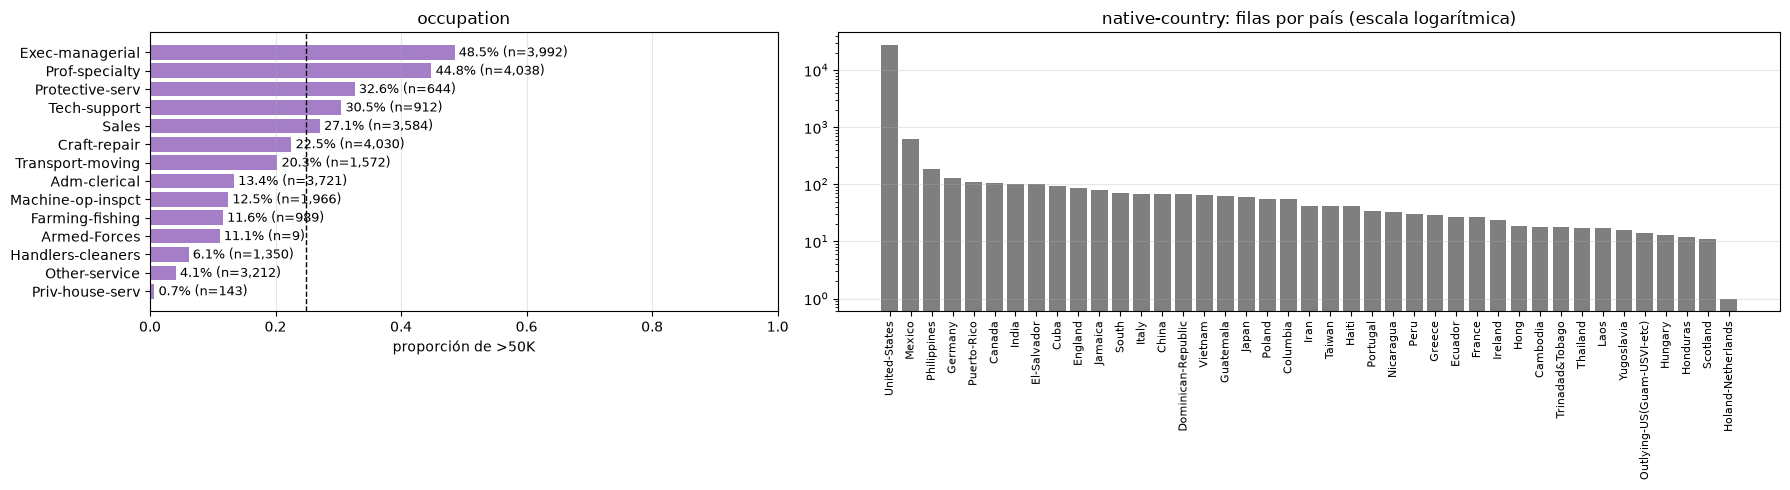

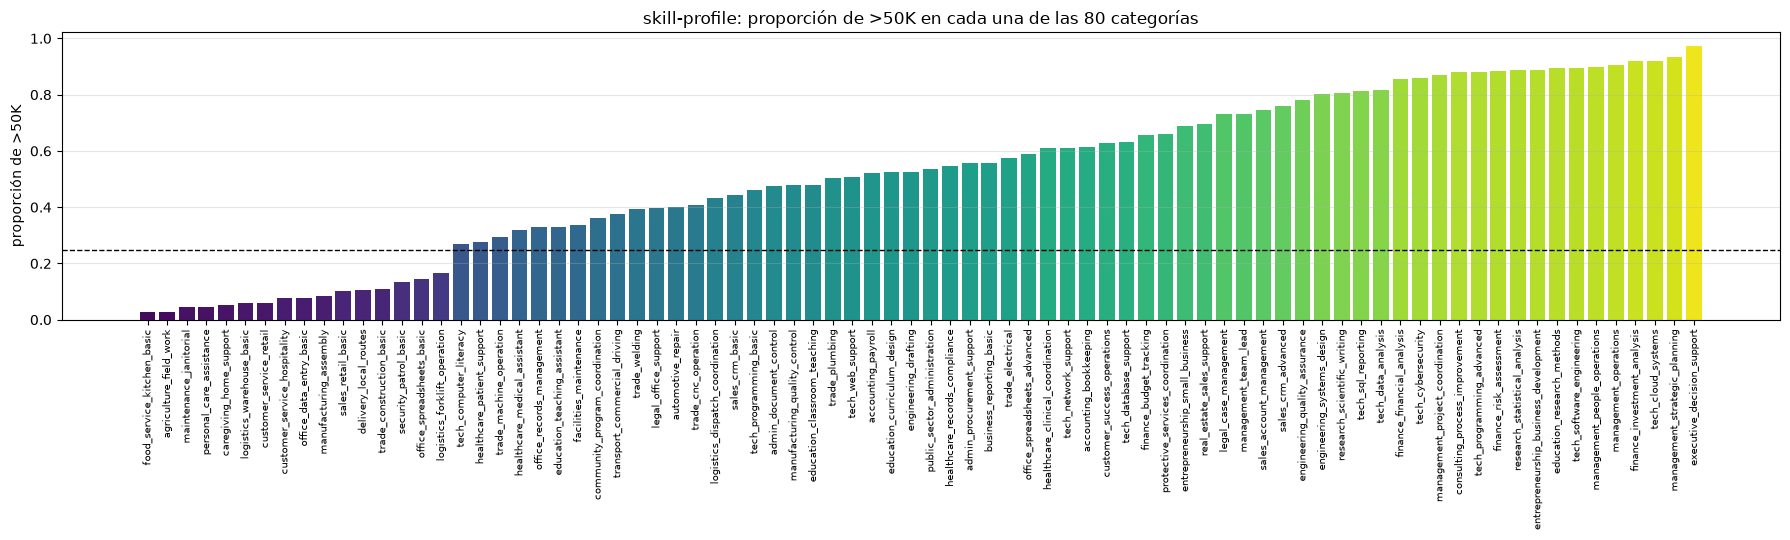

occupation: la proporción de >50K va de 0.7% (Priv-house-serv) a 48.5% (Exec-managerial).
native-country: 91.2% de las filas son United-States, con 25.4% de >50K; el resto de los países juntos tiene 19.3%.
  Mexico, el segundo país, tiene 5.4% en 610 filas. Entre los países con 30 filas o más va de 3.0% (Dominican-Republic) a 45.2% (Taiwan).
  15 de los 41 países tienen menos de 30 filas.
skill-profile: va de 2.7% (food_service_kitchen_basic) a 97.3% (executive_decision_support); en 45 de las 80 categorías la mayoría gana >50K.
  filas por categoría: mínimo 26, mediana 159.
  cada skill aparece con 11 ocupaciones distintas (mediana): no es una subdivisión de occupation.


In [23]:
# ----------------------------------------------------------------------
# ALTA CARDINALIDAD SIN ORDEN: OCCUPATION, NATIVE-COUNTRY Y SKILL-PROFILE
# ----------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 5), gridspec_kw={"width_ratios": [1, 1.5]})
ocup = barras_tasa(axes[0], "occupation")

paises = train["native-country"].value_counts()
axes[1].bar(paises.index, paises.values, color="tab:gray")
axes[1].set_yscale("log"); axes[1].tick_params(axis="x", rotation=90, labelsize=8)
axes[1].set_title("native-country: filas por país (escala logarítmica)"); axes[1].grid(alpha=.3, axis="y")
fig.tight_layout(); plt.show()

sk = alto.groupby(train["skill-profile"]).agg(["size", "mean"]).sort_values("mean")
fig, ax = plt.subplots(figsize=(18, 5.5))
ax.bar(sk.index, sk["mean"], color=plt.cm.viridis(sk["mean"].to_numpy()))
ax.axhline(tasa_global, color="k", ls="--", lw=1)
ax.tick_params(axis="x", rotation=90, labelsize=7)
ax.set_ylabel("proporción de >50K"); ax.grid(alpha=.3, axis="y")
ax.set_title("skill-profile: proporción de >50K en cada una de las 80 categorías")
fig.tight_layout(); plt.show()

print(f"occupation: la proporción de >50K va de {ocup['mean'].min():.1%} ({ocup['mean'].idxmin()}) "
      f"a {ocup['mean'].max():.1%} ({ocup['mean'].idxmax()}).")

pais = alto.groupby(train["native-country"]).agg(["size", "mean"])
grandes = pais.loc[pais["size"] >= 30, "mean"]
es_us = train["native-country"] == "United-States"
print(f"native-country: {es_us.mean():.1%} de las filas son United-States, con {alto[es_us].mean():.1%} de >50K; "
      f"el resto de los países juntos tiene {alto[~es_us].mean():.1%}.")
print(f"  Mexico, el segundo país, tiene {pais.loc['Mexico', 'mean']:.1%} en {pais.loc['Mexico', 'size']} filas. "
      f"Entre los países con 30 filas o más va de {grandes.min():.1%} ({grandes.idxmin()}) a {grandes.max():.1%} ({grandes.idxmax()}).")
print(f"  {(paises < 30).sum()} de los {len(paises)} países tienen menos de 30 filas.")

print(f"skill-profile: va de {sk['mean'].min():.1%} ({sk['mean'].idxmin()}) a {sk['mean'].max():.1%} "
      f"({sk['mean'].idxmax()}); en {(sk['mean'] > 0.5).sum()} de las 80 categorías la mayoría gana >50K.")
print(f"  filas por categoría: mínimo {sk['size'].min()}, mediana {sk['size'].median():.0f}.")
print(f"  cada skill aparece con {train.groupby('skill-profile')['occupation'].nunique().median():.0f} "
      f"ocupaciones distintas (mediana): no es una subdivisión de occupation.")

##### occupation, native-country y skill-profile: alta cardinalidad y sin orden

Las tres son nominales: no hay un orden entre Sales y Tech-support ni entre Mexico y Canada, así que el ordinal queda descartado por la misma razón que antes. Y un one-hot agregaría 14 + 41 + 80 = 135 columnas, casi todas en cero en cada fila. Estas tres son las que van a embedding.

Cada una tiene un perfil distinto:

- occupation separa bastante (V de 0.350): va de 0.7% (Priv-house-serv) a 48.5% (Exec-managerial).
- native-country separa poco (V de 0.103), aunque algo aporta. El 91.2% de las filas son United-States, con 25.4% de >50K, contra 19.3% del resto de los países juntos. Algunos países sí se alejan: Mexico, el segundo, tiene 5.4% en 610 filas, y entre los países con 30 filas o más la proporción va de 3.0% (Dominican-Republic) a 45.2% (Taiwan). El problema es que 15 de los 41 países tienen menos de 30 filas, así que de muchos el modelo va a tener muy poco para aprender.
- skill-profile es por lejos la que más separa (V de 0.623, la más alta de todas). Va de 2.7% (food_service_kitchen_basic) a 97.3% (executive_decision_support), y en 45 de sus 80 categorías la mayoría gana más de 50K. Además cada categoría tiene al menos 26 filas, con una mediana de 159, así que hay datos para aprender algo de cada una.

skill-profile no está entre los atributos del dataset original ([adult.names](https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.names)), así que fue agregada para este caso. No sé cómo se construyó, pero no es una subdivisión de occupation: cada skill aparece combinada con 11 ocupaciones distintas (mediana).

                  count     mean      std   min   25%   50%   75%      max  asimetría  % de ceros
age             30162.0    38.44    13.13  17.0  28.0  37.0  47.0     90.0       0.53        0.00
capital-gain    30162.0  1092.01  7406.35   0.0   0.0   0.0   0.0  99999.0      11.90       91.59
capital-loss    30162.0    88.37   404.30   0.0   0.0   0.0   0.0   4356.0       4.53       95.27
hours-per-week  30162.0    40.93    11.98   1.0  40.0  40.0  45.0     99.0       0.33        0.00


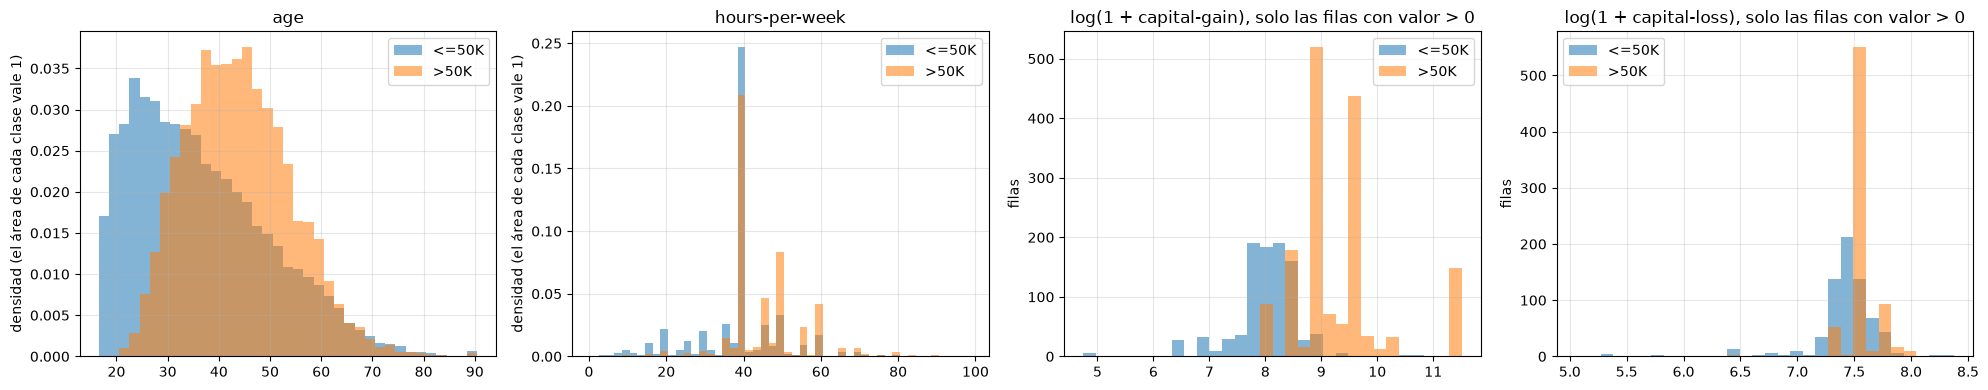


capital-gain por tramos:
                  filas  proporción de >50K
capital-gain                               
[0.0, 1.0)        27624               0.214
[1.0, 3000.0)       414               0.000
[3000.0, 7000.0)    794               0.356
[7000.0, inf)      1330               0.986

capital-loss por tramos:
                  filas  proporción de >50K
capital-loss                               
[0.0, 1.0)        28735               0.236
[1.0, 1800.0)       484               0.116
[1800.0, 2000.0)    648               0.850
[2000.0, inf)       295               0.441

capital-gain = 99999 en 148 filas, y el 100% de ellas es >50K
hours-per-week = 40 en el 47.2% de las filas


In [24]:
# ----------------------------------------------------------------------
# VARIABLES NUMÉRICAS
# ----------------------------------------------------------------------
resumen = train[NUMERICAS].describe().T
resumen["asimetría"] = train[NUMERICAS].skew()
resumen["% de ceros"] = 100 * (train[NUMERICAS] == 0).mean()
print(resumen.round(2).to_string())

# Los mismos bordes de bin para las dos clases, así las barras se pueden comparar
BORDES = {"age": np.arange(16.5, 91.5, 2), "hours-per-week": np.arange(0.5, 100.5, 2)}
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, c in zip(axes[:2], ["age", "hours-per-week"]):
    for clase in CLASES:
        ax.hist(train.loc[train["income"] == clase, c], bins=BORDES[c], density=True, alpha=.55,
                color=COLOR[clase], label=clase)
    ax.set_title(c); ax.set_ylabel("densidad (el área de cada clase vale 1)")
for ax, c in zip(axes[2:], ["capital-gain", "capital-loss"]):
    positivos = train[train[c] > 0]
    bordes = np.histogram_bin_edges(np.log1p(positivos[c]), bins=30)
    for clase in CLASES:
        ax.hist(np.log1p(positivos.loc[positivos["income"] == clase, c]), bins=bordes, alpha=.55,
                color=COLOR[clase], label=clase)
    ax.set_title(f"log(1 + {c}), solo las filas con valor > 0"); ax.set_ylabel("filas")
for a in axes: a.legend(); a.grid(alpha=.3)
fig.tight_layout(); plt.show()

for c, cortes in [("capital-gain", [0, 1, 3000, 7000, np.inf]), ("capital-loss", [0, 1, 1800, 2000, np.inf])]:
    t = alto.groupby(pd.cut(train[c], cortes, right=False), observed=True).agg(["size", "mean"])
    t.columns = ["filas", "proporción de >50K"]
    print(f"\n{c} por tramos:"); print(t.round(3).to_string())

tope = train["capital-gain"] == train["capital-gain"].max()
print(f"\ncapital-gain = {train['capital-gain'].max()} en {tope.sum()} filas, y el {alto[tope].mean():.0%} de ellas es >50K")
print(f"hours-per-week = 40 en el {(train['hours-per-week'] == 40).mean():.1%} de las filas")

##### Numéricas

age y hours-per-week tienen asimetrías bajas (0.53 y 0.33) y las dos separan: los >50K son en general mayores y trabajan más horas. hours-per-week tiene un pico muy marcado en 40, con el 47.2% de las filas. A estas dos solo las estandarizo, para que entren a la red en la misma escala que el resto.

capital-gain y capital-loss son otra cosa. Valen cero en el 91.6% y el 95.3% de las filas, y cuando no son cero pueden ser enormes: la asimetría de capital-gain es 11.9. Si las estandarizara directamente, el máximo de capital-gain quedaría a más de 13 desvíos de la media y esos pocos valores dominarían la primera capa. Por eso primero les aplico log(1 + x), que deja el cero en cero y comprime los valores grandes, y después estandarizo. Los histogramas de la derecha ya están en esa escala.

Cuando no valen cero, lo que importa es el monto. Con capital-gain de menos de 3.000 nadie gana más de 50K (0.0% en 414 filas), y desde 7.000 casi todos (98.6%). En capital-loss ni siquiera es monótono: entre 1.800 y 2.000 el 85.0% es >50K, por encima de 2.000 baja a 44.1%, y con pérdidas chicas es 11.6%, menos que con cero. Por eso no las reduzco a una marca de cero o no cero, que perdería justamente esto. El log conserva el orden de los valores, así que la red puede aprender esos cortes.

capital-gain vale 99999 en 148 filas, y todas son >50K. Parece un valor tope más que un monto real, pero no lo trato distinto: con el log queda como el valor más alto, que es lo que corresponde.

##### Decisión final para cada variable

| variable | valores únicos | transformación | por qué |
|---|---|---|---|
| age | numérica | estandarizar | asimetría baja |
| hours-per-week | numérica | estandarizar | asimetría baja |
| capital-gain | numérica | log(1 + x) y estandarizar | 91.6% de ceros, asimetría 11.9, y el monto importa |
| capital-loss | numérica | log(1 + x) y estandarizar | 95.3% de ceros, asimetría 4.53, y el monto importa |
| sex | 2 | binaria (Male = 1) | con dos valores alcanza una columna |
| race | 5 | one-hot | sin orden y pocos valores |
| relationship | 6 | one-hot | sin orden y pocos valores |
| workclass | 7 | one-hot | sin orden y pocos valores |
| marital-status | 7 | one-hot | sin orden y pocos valores |
| education | 16 (alta) | ordinal de 0 a 15, estandarizada | tiene orden y el target lo respeta (Spearman 0.979) |
| occupation | 14 (alta) | embedding | alta cardinalidad y sin orden |
| native-country | 41 (alta) | embedding | alta cardinalidad y sin orden |
| skill-profile | 80 (alta) | embedding | alta cardinalidad y sin orden |
| income (target) | 2 | 1 si es >50K, 0 si no | clasificación binaria |

Todo lo que se calcula a partir de los datos, la media y el desvío del estandarizado y la lista de categorías de cada variable, sale solamente de train. Validación se transforma con esos mismos valores, para que no influya en ninguna decisión del preprocesamiento.

No descarto ninguna variable: hasta las que menos separan, native-country y race, tienen categorías que se alejan bastante de la proporción global (Mexico 5.4%, Black 13.0%).

## b) Diseño y entrenamiento de un modelo con embeddings (3 puntos)

- Implementar las transformaciones definidas en el punto anterior e incorporarlas al flujo de entrenamiento.
- El modelo debe incluir, como mínimo, una capa de embedding para representar alguna de las variables categóricas.
- La elección de la dimensión del o los embeddings queda a criterio del estudiante, pero debe estar correctamente fundamentada. Recuerden que no es obligatorio que todos los embeddings tengan la misma dimensión.
- La configuración arquitectónica (número de capas, neuronas por capa, función de activación) es de libre elección.
- Incluir dropout en las capas ocultas de la red.
- Utilizar Adam o alguna de sus variantes como optimizador.
- Seleccionar la función de costo apropiada entre Binary CrossEntropyLoss o Categorical CrossEntropyLoss, según la formulación del problema.
- Mostrar las curvas de accuracy vs epoch y F1 macro vs epoch para los sets de entrenamiento y validación.
- Presentar un classification report generado con sklearn.
- Presentar una matriz de confusión absoluta y otra normalizada por fila, correspondientes al set de validación, con una paleta de colores entendible.

#### Respuesta b)

Función de costo. Hay dos clases, así que planteo el problema como binario: la red termina en una sola neurona que da un número, el logit, y la sigmoide lo convierte en la probabilidad de >50K. La función de costo que corresponde a esa salida es la Binary Cross-Entropy. La Categorical Cross-Entropy pediría dos neuronas de salida con softmax, que para dos clases da lo mismo pero con una salida de más, porque las dos probabilidades siempre suman 1. Uso `BCEWithLogitsLoss`, que recibe el logit y aplica la sigmoide adentro: es la misma cuenta que sigmoide más `BCELoss`, pero numéricamente más estable ([documentación de PyTorch](https://pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html)). Para decidir la clase uso el umbral de 0.5 en la probabilidad, que es lo mismo que pedir logit > 0.

Arquitectura. Dos capas ocultas, de 64 y 32 neuronas, con ReLU. Son datos tabulares con 13 variables, así que uso una red chica. Uso ReLU porque para entradas positivas su derivada vale 1, así que no achica el gradiente en la vuelta hacia atrás. La sigmoide lo achica siempre (su derivada vale como mucho 0.25) y la tanh cuando la entrada se aleja de cero. Con dos capas ocultas esto pesa poco, pero ReLU es la opción por defecto y la que usamos en la clase de dropout.

Dropout. 0.3 después de la activación de cada capa oculta, el valor que usamos en esa misma clase. En cada paso de entrenamiento apaga al azar el 30% de las neuronas de esa capa, y así la red no puede depender de ninguna en particular. Al evaluar se desactiva con `modelo.eval()`, y todas las métricas las mido así, también las de train.

Optimizador. Adam con el learning rate por defecto, 1e-3, batches de 256 y 50 épocas. En cada época mezclo train y lo recorro de a 256 filas indexando los tensores directamente, que es lo mismo que hace un `DataLoader` con `shuffle=True`. Con dropout el modelo aprende más lento, y elegí las 50 épocas mirando su curva: a esa altura la pérdida de validación ya casi no baja (0.2617 en la época 30 y 0.2607 en la 50, en la salida del entrenamiento más abajo). Todos los modelos se entrenan esas mismas 50 épocas y reporto siempre la última, sin elegir la mejor época mirando validación.

Semillas. Todo usa semillas fijas, así que en la misma máquina da siempre lo mismo. En otra máquina, por ejemplo en Colab, los decimales del entrenamiento pueden cambiar un poco; los números del texto son los de la ejecución que quedó guardada. Por eso las comparaciones las hago con 3 semillas y miro la media y el desvío, no una sola corrida.

In [25]:
# ----------------------------------------------------------------------
# TRANSFORMACIONES: TODO SE AJUSTA SOLO CON TRAIN
# ----------------------------------------------------------------------
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             classification_report, ConfusionMatrixDisplay)

ONE_HOT   = ["workclass", "marital-status", "relationship", "race"]
EMBEDDING = ["skill-profile", "occupation", "native-country"]

# Una categoría de validación que no estuviera en train quedaría en ceros en el one-hot y en NaN en
# el ordinal sin ningún error. Con estos archivos no pasa (tabla de cardinalidad), pero lo verifico.
assert all(set(val[c]) <= set(train[c]) for c in CATEGORICAS + ["income"])

# El vocabulario de cada categórica sale de train; validación se codifica con ese mismo vocabulario
categorias = {c: sorted(train[c].unique()) for c in ONE_HOT + EMBEDDING}

def numericas(df):
    """Las 4 numéricas (las de capital con log) y education como ordinal, antes de estandarizar."""
    x = df[NUMERICAS].astype(float)
    x["capital-gain"] = np.log1p(x["capital-gain"])
    x["capital-loss"] = np.log1p(x["capital-loss"])
    x["education"] = df["education"].map({e: i for i, e in enumerate(ORDEN_EDUCACION)})
    return x

escalador = StandardScaler().fit(numericas(train))       # media y desvío de train

def entradas_directas(df, a_one_hot):
    """Lo que entra tal cual a la primera capa: las 5 columnas estandarizadas, sex binaria y el one-hot pedido."""
    bloques = [escalador.transform(numericas(df)),
               (df["sex"] == "Male").to_numpy(float).reshape(-1, 1)]
    for c in a_one_hot:
        bloques.append(pd.get_dummies(df[c].astype(pd.CategoricalDtype(categorias[c])), dtype=float).to_numpy())
    return torch.tensor(np.hstack(bloques), dtype=torch.float32)

def entradas_indices(df):
    """Un entero por variable de EMBEDDING: la fila de su tabla de embedding."""
    codigos = np.column_stack([df[c].astype(pd.CategoricalDtype(categorias[c])).cat.codes for c in EMBEDDING])
    return torch.tensor(codigos, dtype=torch.long)

y_train = torch.tensor((train["income"] == ">50K").to_numpy(float), dtype=torch.float32)
y_val   = torch.tensor((val["income"] == ">50K").to_numpy(float), dtype=torch.float32)

X_train_b = (entradas_directas(train, ONE_HOT), entradas_indices(train))
X_val_b   = (entradas_directas(val, ONE_HOT), entradas_indices(val))

print(f"directas: {X_train_b[0].shape[1]} columnas (4 numéricas y education estandarizadas, sex, "
      f"y el one-hot de {', '.join(ONE_HOT)})")
print(f"índices:  {X_train_b[1].shape[1]} columnas enteras, una por variable de embedding")
print(f"\ntrain {tuple(X_train_b[0].shape)} + {tuple(X_train_b[1].shape)}   "
      f"validación {tuple(X_val_b[0].shape)} + {tuple(X_val_b[1].shape)}")
print(f"media de las 5 columnas estandarizadas en validación: {X_val_b[0][:, :5].mean(0).numpy().round(3)} "
      f"(no da 0 exacto: el escalador es de train)")

directas: 31 columnas (4 numéricas y education estandarizadas, sex, y el one-hot de workclass, marital-status, relationship, race)
índices:  3 columnas enteras, una por variable de embedding

train (30162, 31) + (30162, 3)   validación (15060, 31) + (15060, 3)
media de las 5 columnas estandarizadas en validación: [ 0.025 -0.004  0.     0.002 -0.003] (no da 0 exacto: el escalador es de train)


In [26]:
# ----------------------------------------------------------------------
# LA RED Y EL BUCLE DE ENTRENAMIENTO (LOS MISMOS PARA b Y c)
# ----------------------------------------------------------------------
torch.set_num_threads(1)   # la red es tan chica que repartir cada paso entre varios hilos cuesta más de lo que ahorra

SEMILLA   = 0              # la de los modelos que se reportan en b) y c)
SEMILLAS  = (0, 1, 2)      # en las comparaciones cada configuración se entrena con estas 3
CAPAS     = (64, 32)
P_DROPOUT = 0.3
LR        = 1e-3
BATCH     = 256
EPOCAS    = 50

class Red(nn.Module):
    """MLP para datos tabulares. Sin dims_emb no tiene embeddings, que es el modelo del punto c."""
    def __init__(self, n_directas, cardinalidades, dims_emb, p_dropout):
        super().__init__()
        # una tabla por variable: la fila i es el vector aprendido para la categoría i
        self.embeddings = nn.ModuleList(nn.Embedding(n, d) for n, d in zip(cardinalidades, dims_emb))
        ocultas, entrada = [], n_directas + sum(dims_emb)
        for n in CAPAS:
            ocultas += [nn.Linear(entrada, n), nn.ReLU()]
            if p_dropout > 0:
                ocultas.append(nn.Dropout(p_dropout))
            entrada = n
        self.ocultas = nn.Sequential(*ocultas)
        self.salida = nn.Linear(entrada, 1)              # un logit: la sigmoide la aplica la loss

    def forward(self, x_directas, x_indices=None):
        partes = [x_directas] + [emb(x_indices[:, j]) for j, emb in enumerate(self.embeddings)]
        return self.salida(self.ocultas(torch.cat(partes, dim=1))).squeeze(1)


def entrenar(X_tr, X_va, dims_emb=(), p_dropout=0.0, semilla=SEMILLA):
    """Adam con mini-batches durante EPOCAS épocas, siempre con y_train / y_val.
    Devuelve el modelo de la última época y las métricas de cada época."""
    torch.manual_seed(semilla)
    modelo = Red(X_tr[0].shape[1], [len(categorias[c]) for c in EMBEDDING], dims_emb, p_dropout)
    opt = torch.optim.Adam(modelo.parameters(), lr=LR)
    criterio = nn.BCEWithLogitsLoss()
    generador = torch.Generator().manual_seed(semilla)
    historial = []
    for _ in range(EPOCAS):
        modelo.train()                                    # dropout encendido
        orden = torch.randperm(len(y_train), generator=generador)
        for i in range(0, len(y_train), BATCH):           # se recorre train de a BATCH filas
            lote = orden[i:i + BATCH]
            opt.zero_grad()
            criterio(modelo(*[x[lote] for x in X_tr]), y_train[lote]).backward()
            opt.step()

        modelo.eval()                                     # dropout apagado para medir
        with torch.no_grad():
            fila = []
            for X, y in [(X_tr, y_train), (X_va, y_val)]:
                logits = modelo(*X)
                pred, real = (logits > 0).int().numpy(), y.int().numpy()    # logit > 0  <=>  P(>50K) > 0.5
                fila += [criterio(logits, y).item(), accuracy_score(real, pred), f1_score(real, pred, average="macro")]
        historial.append(fila)
    columnas = ["loss_train", "acc_train", "f1_train", "loss_val", "acc_val", "f1_val"]
    return modelo, pd.DataFrame(historial, columns=columnas, index=range(1, EPOCAS + 1))


def predecir(modelo, X):
    modelo.eval()
    with torch.no_grad():
        return (modelo(*X) > 0).int().numpy()


def mostrar_historial(hist):
    tabla = hist.assign(brecha_f1=hist["f1_train"] - hist["f1_val"])      # brecha de F1 entre train y validación
    print(tabla.loc[[1, 5] + list(range(10, EPOCAS + 1, 10))].round(4).to_string())
    print(f"\npérdida de validación mínima: {hist['loss_val'].min():.4f} en la época {hist['loss_val'].idxmin()}")
    print(f"mejor F1 macro de validación: {hist['f1_val'].max():.4f} en la época {hist['f1_val'].idxmax()}")


def media_desvio(valores):
    return f"{np.mean(valores):.4f} ± {np.std(valores, ddof=1):.4f}"


def graficar_curvas(hist, titulo):
    fig, axes = plt.subplots(1, 3, figsize=(17, 4))
    for ax, (clave, nombre) in zip(axes, [("acc", "accuracy"), ("f1", "F1 macro"), ("loss", "pérdida (BCE)")]):
        ax.plot(hist.index, hist[f"{clave}_train"], lw=2, label="train")
        ax.plot(hist.index, hist[f"{clave}_val"], lw=2, label="validación")
        ax.set_title(nombre); ax.set_xlabel("época"); ax.grid(alpha=.3); ax.legend()
    fig.suptitle(titulo); fig.tight_layout(); plt.show()


def evaluar(modelo, X_va, titulo):
    """Classification report y matrices de confusión sobre validación."""
    pred, real = predecir(modelo, X_va), y_val.int().numpy()
    print(classification_report(real, pred, target_names=CLASES, digits=4))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
    for ax, normalizar, formato, nombre in [(axes[0], None, "d", "absoluta"),
                                            (axes[1], "true", ".1%", "normalizada por fila")]:
        ConfusionMatrixDisplay.from_predictions(real, pred, display_labels=CLASES, normalize=normalizar,
                                                values_format=formato, cmap="Blues", ax=ax)
        ax.set_title(f"{titulo}\nmatriz de confusión {nombre}")
        ax.set_xlabel("predicción"); ax.set_ylabel("real")
    fig.tight_layout(); plt.show()

##### Dimensión de los embeddings

Hay reglas prácticas conocidas para elegirla, y dos de ellas no coinciden:

- la raíz cuarta de la cantidad de categorías, que propuso Google al presentar las feature columns de TensorFlow ([blog de Google, 2017](https://developers.googleblog.com/2017/11/introducing-tensorflow-feature-columns.html));
- 1.6 × n^0.56, la que usa fast.ai por defecto ([`emb_sz_rule`](https://github.com/fastai/fastai/blob/master/fastai/tabular/model.py)).

Para skill-profile la primera da 3 y la segunda 19, seis veces más. Hay un argumento a favor de las dimensiones chicas: con un target binario, lo que una categoría aporta a la predicción se puede resumir en muy pocos números. En el extremo alcanzaría con uno solo, cuánto sube o baja la chance de >50K, y las demás dimensiones sirven para combinarse con otras variables. Pero es un argumento, no una prueba, así que entreno el modelo con las dos reglas y comparo.

In [27]:
# ----------------------------------------------------------------------
# ¿QUÉ DIMENSIÓN PARA CADA EMBEDDING? DOS REGLAS QUE NO COINCIDEN
# ----------------------------------------------------------------------
n_cat = {c: len(categorias[c]) for c in EMBEDDING}
reglas = {"raíz cuarta":  tuple(round(n_cat[c] ** 0.25) for c in EMBEDDING),
          "1.6 * n^0.56": tuple(round(1.6 * n_cat[c] ** 0.56) for c in EMBEDDING)}
print(pd.DataFrame({"categorías": n_cat, **{r: dict(zip(EMBEDDING, d)) for r, d in reglas.items()}}).to_string())

# Cada regla con las 3 semillas. Se guardan los modelos: el de la semilla 0 es el que se usa después.
corridas = {r: [entrenar(X_train_b, X_val_b, dims, P_DROPOUT, semilla=s) for s in SEMILLAS]
            for r, dims in reglas.items()}

tabla_dims = pd.DataFrame({r: {
    "parámetros de embedding": sum(n_cat[c] * d for c, d in zip(EMBEDDING, reglas[r])),
    "F1 val final":            media_desvio([h["f1_val"].iloc[-1] for _, h in cs]),
    "F1 train final":          media_desvio([h["f1_train"].iloc[-1] for _, h in cs]),
    "brecha F1 train - val":   media_desvio([h["f1_train"].iloc[-1] - h["f1_val"].iloc[-1] for _, h in cs]),
    "loss val final":          media_desvio([h["loss_val"].iloc[-1] for _, h in cs]),
    "mejor F1 val":            media_desvio([h["f1_val"].max() for _, h in cs]),
} for r, cs in corridas.items()})
print(f"\n{EPOCAS} épocas, media ± desvío entre las semillas {SEMILLAS}:\n")
print(tabla_dims.to_string())

                categorías  raíz cuarta  1.6 * n^0.56
skill-profile           80            3            19
occupation              14            2             7
native-country          41            3            13

50 épocas, media ± desvío entre las semillas (0, 1, 2):

                             raíz cuarta     1.6 * n^0.56
parámetros de embedding              391             2151
F1 val final             0.8482 ± 0.0013  0.8381 ± 0.0008
F1 train final           0.8634 ± 0.0011  0.8734 ± 0.0010
brecha F1 train - val    0.0153 ± 0.0005  0.0353 ± 0.0015
loss val final           0.2576 ± 0.0030  0.2706 ± 0.0011
mejor F1 val             0.8494 ± 0.0024  0.8459 ± 0.0006


En su mejor época las dos reglas llegan a valores parecidos (0.8494 y 0.8459 de F1 macro en validación), pero terminan distinto: 0.8482 con la raíz cuarta y 0.8381 con la de fast.ai. Esa diferencia es varias veces el desvío entre semillas (0.0013 y 0.0008), aunque con solo 3 semillas ese desvío es una estimación gruesa. Lo más claro es la brecha con train: 0.0153 con la raíz cuarta y 0.0353 con la otra, más del doble, y la pérdida de validación final también es más baja (0.2576 contra 0.2706). Las dimensiones de más no le dan información nueva al modelo, le dan más lugar para aprenderse train.

Me quedo con la raíz cuarta: 3 dimensiones para skill-profile, 2 para occupation y 3 para native-country. Son 391 parámetros entre las tres tablas, contra 2.151 de la otra regla.

Una limitación de la regla es que solo mira cuántas categorías tiene la variable, no cuánto informa. Por eso le da más dimensiones a native-country que a occupation, aunque occupation separa mucho más (V de 0.350 contra 0.103). La dejo igual para no seguir ajustando a mano mirando validación.

In [28]:
# ----------------------------------------------------------------------
# EL MODELO CON EMBEDDINGS
# ----------------------------------------------------------------------
DIMS = reglas["raíz cuarta"]
modelo_b, hist_b = corridas["raíz cuarta"][SEMILLAS.index(SEMILLA)]    # ya entrenado en la comparación de arriba

print(modelo_b)
n_emb = sum(e.weight.numel() for e in modelo_b.embeddings)
print(f"\nparámetros: {sum(p.numel() for p in modelo_b.parameters()):,} en total, {n_emb} de ellos en los embeddings")
print(f"primera capa: recibe {X_train_b[0].shape[1]} directas + {sum(DIMS)} de embeddings = "
      f"{modelo_b.ocultas[0].in_features} entradas\n")
mostrar_historial(hist_b)

Red(
  (embeddings): ModuleList(
    (0): Embedding(80, 3)
    (1): Embedding(14, 2)
    (2): Embedding(41, 3)
  )
  (ocultas): Sequential(
    (0): Linear(in_features=39, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
  )
  (salida): Linear(in_features=32, out_features=1, bias=True)
)

parámetros: 5,064 en total, 391 de ellos en los embeddings
primera capa: recibe 31 directas + 8 de embeddings = 39 entradas

    loss_train  acc_train  f1_train  loss_val  acc_val  f1_val  brecha_f1
1       0.3476     0.8374    0.7752    0.3457   0.8401  0.7777    -0.0026
5       0.2942     0.8698    0.8185    0.2988   0.8658  0.8095     0.0089
10      0.2694     0.8843    0.8423    0.2757   0.8819  0.8363     0.0061
20      0.2533     0.8921    0.8500    0.2643   0.8882  0.8412     0.0087
30      0.2466     0.8942    0.8549    0.2617   0.8893  0.8451    

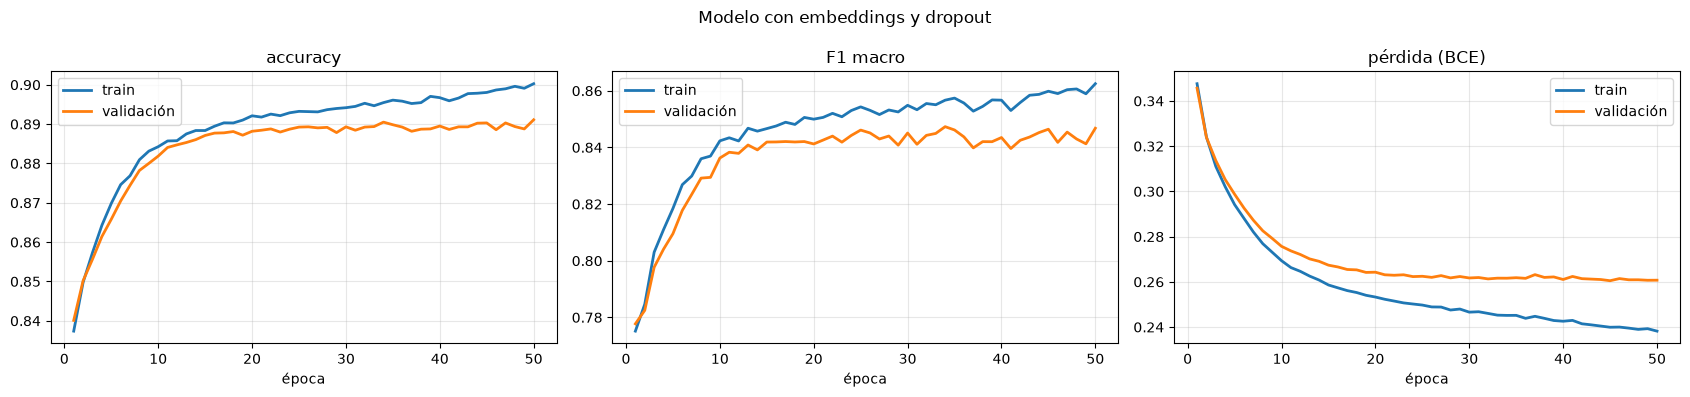

In [29]:
graficar_curvas(hist_b, "Modelo con embeddings y dropout")

              precision    recall  f1-score   support

       <=50K     0.9119    0.9472    0.9292     11360
        >50K     0.8160    0.7189    0.7644      3700

    accuracy                         0.8911     15060
   macro avg     0.8639    0.8331    0.8468     15060
weighted avg     0.8883    0.8911    0.8887     15060



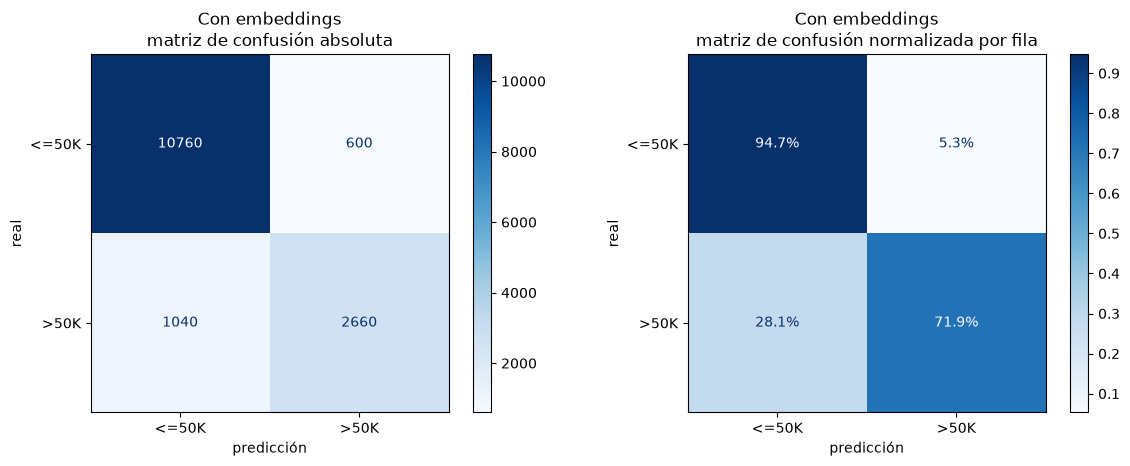

In [30]:
evaluar(modelo_b, X_val_b, "Con embeddings")

##### Resultados

El modelo termina con accuracy 0.8911 y F1 macro 0.8468 en validación. Para ubicar el accuracy: responder siempre <=50K daba 75.4%, así que el modelo elimina más de la mitad de los errores de no mirar los datos.

Las curvas muestran un entrenamiento estable. Train y validación suben juntas las primeras 10 épocas, y después train sigue mejorando despacio mientras validación se aplana. A las 50 épocas la brecha de F1 macro es de 0.0157, y la pérdida de validación (0.2607) está prácticamente en su mínimo (0.2605, en la época 45). En estas 50 épocas no aparece sobreajuste.

Las dos clases no se predicen igual de bien. De los <=50K reales el modelo reconoce el 94.7%, pero de los >50K solo el 71.9%: se le escapan 1.040 de las 3.700 personas que ganan más de 50K. El error contrario es mucho más raro en proporción, 600 personas, el 5.3% de los <=50K. El modelo dice >50K 3.260 veces (2.660 bien y 600 mal), no tan lejos de las 3.700 reales, así que el problema no es tanto cuántas veces lo dice sino a quién. Hay personas con perfiles parecidos en las dos clases, y con el umbral de 0.5 el modelo se inclina por la clase grande, que en train tiene tres veces más ejemplos.

## c) Diseño y entrenamiento de un modelo sin embeddings (3 puntos)

- Entrenar un segundo modelo, aplicando one-hot encoding a todas las variables que en el punto b) fueron representadas mediante embeddings.
- Quitar todas las capas de dropout, para este segundo modelo no se usará ninguna capa interna de regularización.
- Con respecto al resto de capas, se debe mantener exactamente la misma arquitectura del modelo anterior: igual número de capas, misma cantidad de neuronas por capa y mismas funciones de activación.
- Presentar las mismas métricas, visualizaciones y reportes que en el modelo con embeddings.

#### Respuesta c)

El segundo modelo cambia dos cosas y deja todo lo demás igual:

- skill-profile, occupation y native-country pasan de embedding a one-hot: 80 + 14 + 41 = 135 columnas que reemplazan a las 3 columnas de índices. La primera capa pasa de recibir 39 números a recibir 166.
- No tiene ninguna capa de Dropout.

Las capas ocultas son las mismas, 64 y 32 neuronas con ReLU, y también el optimizador, el learning rate, el batch, las 50 épocas y la semilla. La celda verifica con `assert` que las capas coincidan con las del modelo con embeddings y que no quede ningún Dropout. El resto de las variables mantienen su transformación; education sigue como ordinal.

In [31]:
# ----------------------------------------------------------------------
# MODELO SIN EMBEDDINGS: TODO ONE-HOT Y SIN DROPOUT
# ----------------------------------------------------------------------
X_train_c = (entradas_directas(train, ONE_HOT + EMBEDDING),)
X_val_c   = (entradas_directas(val, ONE_HOT + EMBEDDING),)

modelo_c, hist_c = entrenar(X_train_c, X_val_c, dims_emb=(), p_dropout=0.0)
print(modelo_c)

# Mismas capas ocultas que el modelo b (mismo tipo, mismo orden, mismas neuronas) y ningún Dropout
capas_b = [m for m in modelo_b.ocultas if not isinstance(m, nn.Dropout)]
assert [type(m) for m in modelo_c.ocultas] == [type(m) for m in capas_b]
assert [m.out_features for m in modelo_c.ocultas if isinstance(m, nn.Linear)] == \
       [m.out_features for m in capas_b if isinstance(m, nn.Linear)]
assert not any(isinstance(m, nn.Dropout) for m in modelo_c.modules())

print(f"\nentradas: {X_train_c[0].shape[1]} columnas = {X_train_b[0].shape[1]} directas del modelo b + "
      f"{' + '.join(str(n_cat[c]) for c in EMBEDDING)} del one-hot de {', '.join(EMBEDDING)}")
print(f"parámetros: {sum(p.numel() for p in modelo_c.parameters()):,}\n")
mostrar_historial(hist_c)

Red(
  (embeddings): ModuleList()
  (ocultas): Sequential(
    (0): Linear(in_features=166, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
  )
  (salida): Linear(in_features=32, out_features=1, bias=True)
)

entradas: 166 columnas = 31 directas del modelo b + 80 + 14 + 41 del one-hot de skill-profile, occupation, native-country
parámetros: 12,801

    loss_train  acc_train  f1_train  loss_val  acc_val  f1_val  brecha_f1
1       0.2880     0.8737    0.8283    0.2853   0.8763  0.8296    -0.0014
5       0.2548     0.8902    0.8448    0.2641   0.8863  0.8362     0.0086
10      0.2434     0.8954    0.8578    0.2600   0.8895  0.8470     0.0109
20      0.2332     0.9010    0.8604    0.2703   0.8864  0.8367     0.0237
30      0.2200     0.9061    0.8683    0.2780   0.8846  0.8345     0.0337
40      0.2067     0.9123    0.8783    0.2871   0.8810  0.8312     0.0470
50      0.1938     0.9201    0.8888    0.3048   0.8787  0.8

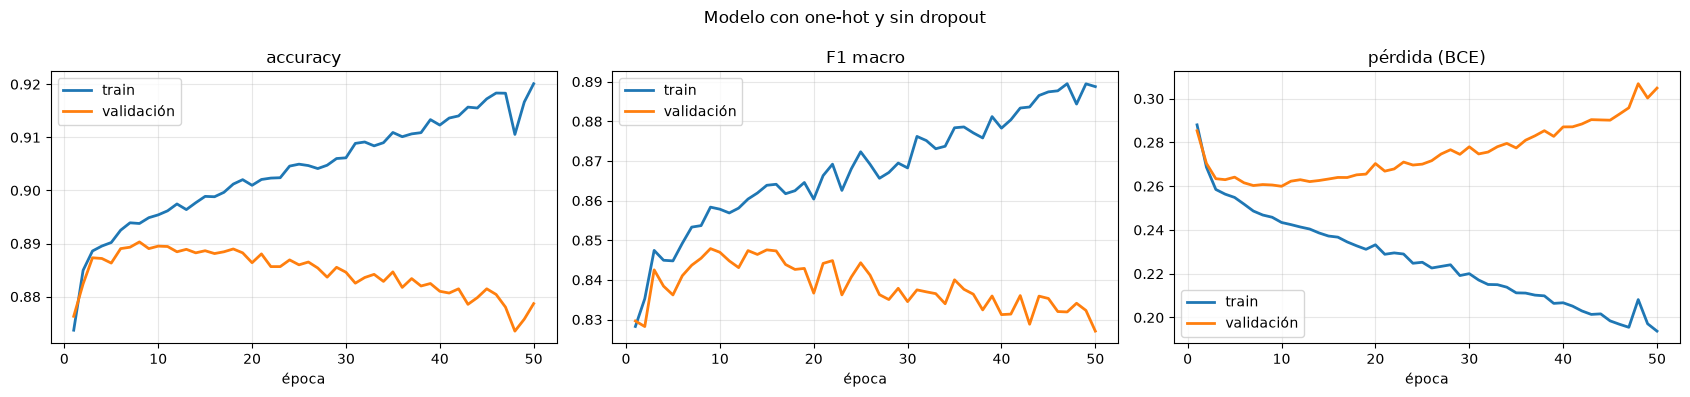

In [32]:
graficar_curvas(hist_c, "Modelo con one-hot y sin dropout")

              precision    recall  f1-score   support

       <=50K     0.8996    0.9445    0.9215     11360
        >50K     0.7989    0.6765    0.7326      3700

    accuracy                         0.8787     15060
   macro avg     0.8493    0.8105    0.8271     15060
weighted avg     0.8749    0.8787    0.8751     15060



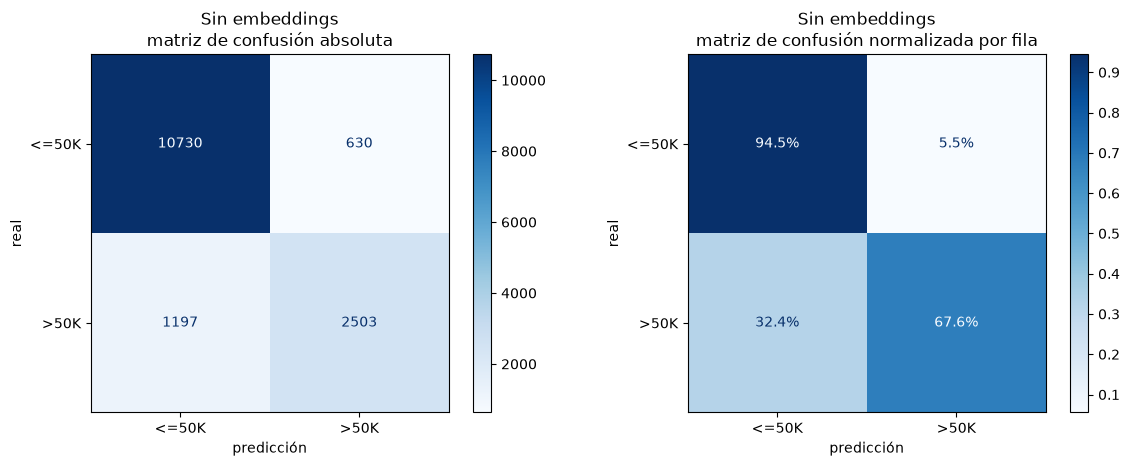

In [33]:
evaluar(modelo_c, X_val_c, "Sin embeddings")

##### Resultados

Este modelo arranca mucho más rápido. Después de la primera época ya tiene 0.8296 de F1 macro en validación, cuando el modelo con embeddings estaba en 0.7777. Tiene sentido: con one-hot cada categoría tiene su propia columna de 64 pesos en la primera capa, mientras que con embeddings tiene que pasar por un vector de 3 números que arranca al azar.

Pero después se sobreajusta de libro. La pérdida de validación toca su mínimo en la época 10 (0.2600) y desde ahí sube, hasta terminar en 0.3048, mientras la de train sigue bajando hasta 0.1938. En F1 macro pasa lo mismo: train sube a 0.8888 y validación baja a 0.8271, una brecha de 0.0617. Desde la época 10 el modelo deja de aprender cosas que sirven para personas nuevas y se dedica a memorizar las de train.

El sobreajuste le pega más a la clase chica. Comparado con el modelo con embeddings, el F1 de >50K baja de 0.7644 a 0.7326, y el de <=50K apenas de 0.9292 a 0.9215. En esta corrida se le escapan 1.197 personas que ganan más de 50K (recall de 67.6%, contra 71.9% del modelo con embeddings).


## d) Conclusiones finales (2 puntos)

- Elaborar una tabla comparativa con los resultados obtenidos por ambos modelos. No solo comparar métricas de precisión, sino también la cantidad final de parámetros y entradas.
- Redactar detalladamente sus observaciones y apreciaciones derivadas de la comparación y plantear conclusiones fundamentadas respecto al desempeño de cada enfoque, justificando por qué uno funciona mejor o peor según las características del problema.

#### Respuesta d)

La tabla de abajo compara los modelos al final de las 50 épocas, con 3 semillas cada uno. Agregué una tercera columna de control: el modelo sin embeddings pero con el mismo dropout que el primero. Los modelos b y c difieren en dos cosas a la vez, el encoding y el dropout, y sin ese control no podría separar qué aporta cada una.

Al final de las 50 épocas. Media ± desvío entre las semillas (0, 1, 2); la semilla 0 es la de los reportes de b) y c).

                       b) embeddings + dropout c) one-hot, sin dropout control: one-hot + dropout
accuracy val                   0.8920 ± 0.0008         0.8768 ± 0.0025            0.8808 ± 0.0027
F1 macro val                   0.8482 ± 0.0013         0.8296 ± 0.0022            0.8331 ± 0.0053
precision >50K                 0.8170 ± 0.0035         0.7697 ± 0.0294            0.7880 ± 0.0029
recall >50K                    0.7222 ± 0.0052         0.7145 ± 0.0368            0.7044 ± 0.0183
F1 macro train                 0.8634 ± 0.0011         0.8922 ± 0.0030            0.8889 ± 0.0010
brecha F1 train - val          0.0153 ± 0.0005         0.0625 ± 0.0009            0.0559 ± 0.0053
loss val final                 0.2576 ± 0.0030         0.3079 ± 0.0078            0.2840 ± 0.0038
loss val mínima                0.2573 ± 0.0032         0.2602 ± 0.0003            0.2612 ± 0.000

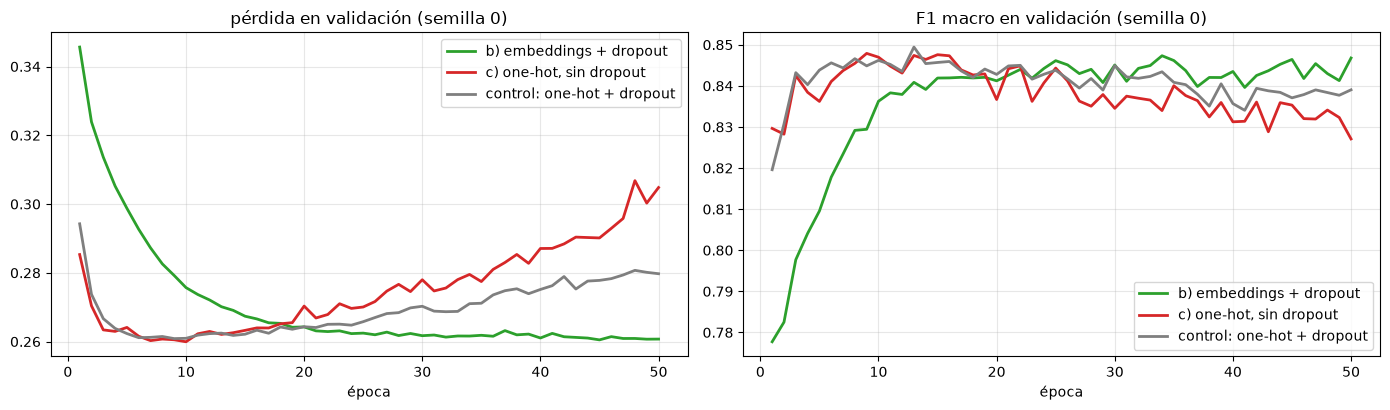

In [34]:
# ----------------------------------------------------------------------
# TABLA COMPARATIVA, 3 SEMILLAS POR MODELO
# ----------------------------------------------------------------------
# b ya tiene sus 3 semillas de la comparación de dimensiones y c tiene la semilla 0. Se entrena lo que falta.
# Control: el modelo c con el dropout del b, para separar lo que aporta el encoding de lo que aporta el dropout.
modelos = {
    "b) embeddings + dropout":    (corridas["raíz cuarta"], X_val_b),
    "c) one-hot, sin dropout":    ([(modelo_c, hist_c)] + [entrenar(X_train_c, X_val_c, semilla=s) for s in SEMILLAS[1:]], X_val_c),
    "control: one-hot + dropout": ([entrenar(X_train_c, X_val_c, p_dropout=P_DROPOUT, semilla=s) for s in SEMILLAS], X_val_c),
}

def resumen(corridas_modelo, X_va):
    real = y_val.int().numpy()
    preds = [predecir(m, X_va) for m, _ in corridas_modelo]
    hists = [h for _, h in corridas_modelo]
    modelo = corridas_modelo[0][0]
    primera = modelo.ocultas[0]
    return {
        "accuracy val":           media_desvio([h["acc_val"].iloc[-1] for h in hists]),
        "F1 macro val":           media_desvio([h["f1_val"].iloc[-1] for h in hists]),
        "precision >50K":         media_desvio([precision_score(real, p) for p in preds]),
        "recall >50K":            media_desvio([recall_score(real, p) for p in preds]),
        "F1 macro train":         media_desvio([h["f1_train"].iloc[-1] for h in hists]),
        "brecha F1 train - val":  media_desvio([h["f1_train"].iloc[-1] - h["f1_val"].iloc[-1] for h in hists]),
        "loss val final":         media_desvio([h["loss_val"].iloc[-1] for h in hists]),
        "loss val mínima":        media_desvio([h["loss_val"].min() for h in hists]),
        "mejor F1 val":           media_desvio([h["f1_val"].max() for h in hists]),
        "época del mejor F1 val": ", ".join(str(h["f1_val"].idxmax()) for h in hists),
        "columnas de entrada":    f"{sum(x.shape[1] for x in X_va)}",
        "entradas a la 1ra capa": f"{primera.in_features}",
        "parámetros embeddings":  f"{sum(e.weight.numel() for e in modelo.embeddings):,}",
        "parámetros 1ra capa":    f"{primera.weight.numel() + primera.bias.numel():,}",
        "parámetros totales":     f"{sum(p.numel() for p in modelo.parameters()):,}",
    }

comparacion = pd.DataFrame({nombre: resumen(cm, X_va) for nombre, (cm, X_va) in modelos.items()})
print(f"Al final de las {EPOCAS} épocas. Media ± desvío entre las semillas {SEMILLAS}; "
      f"la semilla {SEMILLA} es la de los reportes de b) y c).\n")
print(comparacion.to_string())

# ¿En qué época llegan los modelos con one-hot al ajuste de train que el b tiene al final?
loss_b_final = [h["loss_train"].iloc[-1] for _, h in corridas["raíz cuarta"]]
for nombre in ["c) one-hot, sin dropout", "control: one-hot + dropout"]:
    epocas = [h.index[h["loss_train"] <= lb].min() for (_, h), lb in zip(modelos[nombre][0], loss_b_final)]
    print(f"\n{nombre}: llega a la pérdida de train que b tiene en la época {EPOCAS} en las épocas {epocas}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
for (nombre, (cm, _)), color in zip(modelos.items(), ["tab:green", "tab:red", "tab:gray"]):
    h = cm[SEMILLAS.index(SEMILLA)][1]
    axes[0].plot(h.index, h["loss_val"], color=color, lw=2, label=nombre)
    axes[1].plot(h.index, h["f1_val"], color=color, lw=2, label=nombre)
axes[0].set_title(f"pérdida en validación (semilla {SEMILLA})"); axes[1].set_title(f"F1 macro en validación (semilla {SEMILLA})")
for a in axes: a.set_xlabel("época"); a.grid(alpha=.3); a.legend()
fig.tight_layout(); plt.show()

##### Qué muestra la tabla

Al final del entrenamiento el modelo con embeddings es mejor que el de one-hot en todas las métricas de validación: accuracy 0.8920 contra 0.8768 y F1 macro 0.8482 contra 0.8296, con desvíos entre semillas de 0.0025 o menos. La diferencia más grande está en la precision de >50K, 0.8170 contra 0.7697: el modelo con one-hot se equivoca más cuando dice >50K, aunque de una semilla a otra varía bastante (± 0.0294). El recall de >50K queda parecido (0.7222 contra 0.7145). Y todo con 2.5 veces menos parámetros, 5.064 contra 12.801, una diferencia que está toda en la primera capa: 2.560 parámetros más 391 de embeddings contra 10.688, con las capas siguientes idénticas. En entradas, el modelo con embeddings recibe 34 columnas (31 directas y 3 índices) y su primera capa ve 39 números; el de one-hot recibe y ve 166.

Pero no es que el one-hot tenga menos información. En su mejor época los tres modelos llegan prácticamente a lo mismo, 0.8494, 0.8471 y 0.8466 de F1 macro, diferencias del tamaño del ruido entre semillas. Lo que cambia es cuándo llegan y qué pasa después: los modelos con one-hot tienen su mejor época entre la 6 y la 18 y después empeoran, y el de embeddings llega entre la 34 y la 48 y se queda ahí.

##### Por qué

Una capa lineal que recibe un one-hot es en realidad un embedding. Al multiplicar un vector de ceros con un solo 1 por la matriz de pesos, lo único que sobrevive es la columna de esa categoría: 64 números. O sea que el modelo sin embeddings también aprende un vector para cada skill-profile, solo que de dimensión 64 y metido adentro de la primera capa. El modelo con embeddings obliga a que esos 64 números salgan de solo 3, combinados con pesos que comparten todas las categorías.

Con tan pocos números por categoría, el modelo se aprende train mucho más despacio. Los dos modelos con one-hot llegan a la pérdida de train que el de embeddings tiene en la época 50 entre las épocas 15 y 21, entre dos y tres veces más rápido, y desde ahí siguen memorizando. El embedding no impide memorizar: incluso en ese modelo la brecha de F1 crece despacio (0.0061 en la época 10, 0.0098 en la 30 y 0.0157 en la 50). Lo que hace es que el tramo en el que el modelo generaliza bien dure mucho más. Es la misma escala que apareció al elegir la dimensión: con dropout, la brecha a las 50 épocas es 0.0153 con 3 dimensiones, 0.0353 con 19 y 0.0559 con el one-hot, que equivale a 64.

El control separa los dos cambios. El dropout solo, sobre el one-hot, mejora la pérdida de validación (de 0.3079 a 0.2840), pero el F1 macro casi no cambia (de 0.8296 a 0.8331, dentro del ruido entre semillas) y la brecha con train sigue alta (0.0559). Pasar después a embeddings, con el mismo dropout, baja la pérdida a 0.2576, sube el F1 a 0.8482 y deja la brecha en 0.0153. En la pérdida los dos cambios aportan parecido, pero en el F1 y en la brecha el que pesa es el encoding.

##### Conclusión

Los dos enfoques pueden llegar al mismo F1, pero el de embeddings es mejor para este problema: usa 2.5 veces menos parámetros, se sostiene en su mejor nivel durante muchas más épocas, y con el mismo entrenamiento termina mejor. El one-hot sin regularización alcanza lo mismo solo si se lo frena alrededor de la época 10, y frenar a tiempo (early stopping) ya es una forma de regularizar, justo lo que este modelo no tiene.